In [1]:
import os
import pandas as pd
import random
import shutil

In [2]:
!pip install mediapipe 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 40.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 15.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 4.25.6 which is incompatible.
google-cloud-bigtable 2.27.0 requires google-api-core[grpc]<3.0.0dev,>=2.16.0, but you have google-api-core 1.34.1 which is incompatible.
pandas-gbq 0.25.0 requires google-api-core<3.0.0dev,>=2.10.2, but you have google-api-core 1.34.1 which is incompatible.
tensorflow-decision-forests 1.10.0 requires tens

In [3]:
import os
import numpy as np
import cv2
import mediapipe as mp
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from sklearn.model_selection import train_test_split
import joblib  # For saving keypoints
from tqdm import tqdm

# Set dataset path
DATASET_PATH = "/kaggle/input/indian-sign-language-isl/Indian"

# Initialize MediaPipe Hands (instead of Holistic)
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.3)

# Expected feature count: 21 landmarks x 2 hands x 2 (x,y) = 84
EXPECTED_FEATURES = 84

# Function to extract hand keypoints
def extract_hand_keypoints(image):
    # Convert to RGB for MediaPipe
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Process with MediaPipe Hands
    results = hands.process(image_rgb)
    
    # Initialize placeholders for hand keypoints
    left_hand = np.zeros(21 * 2)  # 42 features (21 landmarks × x, y)
    right_hand = np.zeros(21 * 2)  # 42 features (21 landmarks × x, y)
    
    # Extract keypoints if hands are detected
    if results.multi_hand_landmarks:
        for hand_idx, hand_landmarks in enumerate(results.multi_hand_landmarks):
            hand_keypoints = []
            for landmark in hand_landmarks.landmark:
                hand_keypoints.append(landmark.x)
                hand_keypoints.append(landmark.y)
            
            # Assign to left or right hand (simplification - first detected hand is left, second is right)
            if hand_idx == 0:
                left_hand = np.array(hand_keypoints)
            elif hand_idx == 1:
                right_hand = np.array(hand_keypoints)
    
    # Concatenate left & right hand keypoints
    return np.concatenate([left_hand, right_hand])

# Lists to store keypoints and labels
keypoints_data = []
labels = []

# Create a label mapping dictionary
unique_labels = sorted(os.listdir(DATASET_PATH))
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}

# Load dataset and extract keypoints
for label in tqdm(sorted(os.listdir(DATASET_PATH))):
    print({'Started->': label})  # Iterate over class folders
    label_path = os.path.join(DATASET_PATH, label)
    
    if os.path.isdir(label_path):
        for image_name in os.listdir(label_path):
            image_path = os.path.join(label_path, image_name)
            
            # Read image
            image = cv2.imread(image_path)
            if image is None:
                continue  # Skip corrupted images
            
            # Resize for consistency and faster processing
            image = cv2.resize(image, (256, 256))
                
            # Extract keypoints
            keypoints = extract_hand_keypoints(image)
            
            # Ensure consistency in feature count
            if len(keypoints) == EXPECTED_FEATURES:
                keypoints_data.append(keypoints)
                labels.append(label_to_index[label])
            else:
                print(f"⚠ Skipped {image_name} in {label}: Incorrect features ({len(keypoints)} instead of {EXPECTED_FEATURES})")

# Convert to NumPy arrays
X = np.array(keypoints_data)
y = np.array(labels)

# Save extracted keypoints (for future use)
# Also save the label mapping for later reference
joblib.dump((X, y, label_to_index), "/kaggle/working/hand_keypoints_data.pkl")
print(f"✅ Keypoints extracted and saved! Shape: {X.shape}")

# Print the mapping in a more readable format
print("Label mapping (folder name -> index):")
for label, index in sorted(label_to_index.items()):
    print(f"  {label} -> {index}")
print(f"Total number of classes: {len(label_to_index)}")

# Split dataset into train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(f"Dataset split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

# Reshape for CNN input
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1], 1)

  0%|          | 0/35 [00:00<?, ?it/s]

{'Started->': '1'}


  3%|▎         | 1/35 [00:46<26:16, 46.37s/it]

{'Started->': '2'}


  6%|▌         | 2/35 [01:33<25:37, 46.59s/it]

...

{'Started->': 'Y'}


 97%|█████████▋| 34/35 [31:18<00:58, 58.14s/it]

{'Started->': 'Z'}


100%|██████████| 35/35 [32:20<00:00, 55.44s/it]

✅ Keypoints extracted and saved! Shape: (42745, 84)
Label mapping (folder name -> index):
  1 -> 0
  2 -> 1
  3 -> 2
  4 -> 3
  5 -> 4
  6 -> 5
  7 -> 6
  8 -> 7
  9 -> 8
  A -> 9
  B -> 10
  C -> 11
  D -> 12
  E -> 13
  F -> 14
  G -> 15
  H -> 16
  I -> 17
  J -> 18
  K -> 19
  L -> 20
  M -> 21
  N -> 22
  O -> 23
  P -> 24
  Q -> 25
  R -> 26
  S -> 27
  T -> 28
  U -> 29
  V -> 30
  W -> 31
  X -> 32
  Y -> 33
  Z -> 34
Total number of classes: 35
Dataset split: Train=29921, Val=6412, Test=6412


In [15]:
X[2000]

array([0.49337131, 0.87669051, 0.40026101, 0.81583714, 0.37570071,
       0.70565677, 0.46860358, 0.61983091, 0.55731165, 0.56712359,
       0.37234133, 0.48418462, 0.32839647, 0.32015997, 0.30420023,
       0.21322738, 0.28733182, 0.12215495, 0.47772187, 0.47223419,
       0.48709375, 0.28916842, 0.49813354, 0.17207149, 0.50497186,
       0.07172838, 0.562805  , 0.51493084, 0.61510956, 0.39154229,
       0.60019916, 0.46738788, 0.57803661, 0.53857332, 0.63211542,
       0.59065336, 0.66800237, 0.51043105, 0.64188534, 0.55922031,
       0.61109102, 0.61947846, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [4]:
# Check size mismatch
print(f"X shape: {X.shape}, y shape: {y.shape}")

# If X has more samples than y, remove extra entries
if X.shape[0] > y.shape[0]:
    print(f"Trimming X from {X.shape[0]} to {y.shape[0]} samples")
    X = X[:len(y)]  # Trim extra samples

# If y has more labels than X, remove extra labels (rare case)
elif y.shape[0] > X.shape[0]:
    print(f"Trimming y from {y.shape[0]} to {X.shape[0]} labels")
    y = y[:len(X)]

# Confirm both have the same length
print(f"After trimming: X shape = {X.shape}, y shape = {y.shape}")

# Now proceed with splitting
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Dataset split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")


X shape: (42745, 84), y shape: (42745,)
After trimming: X shape = (42745, 84), y shape = (42745,)
Dataset split: Train=29921, Val=6412, Test=6412


In [5]:
num_classes = 35

In [6]:
import os
import cv2
import numpy as np
import mediapipe as mp
import random
import pickle
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

In [19]:
y_train_cat = to_categorical(y_train - 1, num_classes=num_classes)  # subtract 1 if folder names start at 1
y_val_cat   = to_categorical(y_val - 1, num_classes=num_classes)
y_test_cat  = to_categorical(y_test - 1, num_classes=num_classes)

array([0., 0., 0., ..., 0., 0., 0.])

In [7]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# # Load the dataset (Ensure this file exists)
# dataset_path = "/kaggle/working/keypoints_data.pkl"

# with open(dataset_path, "rb") as f:
#     dataset = pickle.load(f)

# X = np.array(dataset["data"])
# y = np.array(dataset["labels"])

# Split dataset into Train (70%), Validation (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Dataset Split: Train={len(X_train)}, Validation={len(X_val)}, Test={len(X_test)}")

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluate the model
y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Save the trained model
model_path = "/kaggle/working/random_forest_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(rf_model, f)

# Display results
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Model saved at: {model_path}")


Dataset Split: Train=29921, Validation=6412, Test=6412
Train Accuracy: 0.9943
Validation Accuracy: 0.9939
Test Accuracy: 0.9925
Model saved at: /kaggle/working/random_forest_model.pkl


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
print("\n📌 Classification Report:\n")
print(classification_report(y_test, y_test_pred))





📌 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00       180
           2       1.00      1.00      1.00       180
           3       1.00      1.00      1.00       180
           4       1.00      1.00      1.00       180
           5       1.00      1.00      1.00       180
           6       1.00      1.00      1.00       180
           7       1.00      1.00      1.00       180
           8       1.00      1.00      1.00       180
           9       0.99      1.00      1.00       180
          10       1.00      1.00      1.00       180
          11       0.99      0.88      0.94       217
          12       1.00      1.00      1.00       180
          13       1.00      1.00      1.00       180
          14       1.00      1.00      1.00       180
          15       1.00      0.99      1.00       180
          16       1.00      0.99      1.00       180


In [12]:


import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [13]:
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# ✅ Enable mixed precision for faster GPU training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# # ✅ Load dataset
# dataset_path = "/kaggle/input/hand-keypoints/hand_keypoints_data.pkl"
# with open(dataset_path, "rb") as f:
#     dataset = pickle.load(f)

# X = np.array(dataset["data"])  # Shape: (samples, 84)
# y = np.array(dataset["labels"])  # Already in numerical format

# ✅ Convert labels to one-hot encoding
y_categorical = to_categorical(y)  # Shape: (samples, num_classes)

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, stratify=y_categorical, random_state=42)

# ✅ Reshape input for LSTM: (samples, time steps=1, features=84)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# ✅ Model Checkpoint (Save Best Model)
checkpoint = ModelCheckpoint("/kaggle/working/best_lstm_model.keras", 
                             monitor="val_categorical_accuracy", 
                             save_best_only=True, 
                             mode="max", 
                             verbose=1)

# ✅ Early Stopping (Stops training if no improvement for 10 epochs)
early_stopping = EarlyStopping(monitor="val_categorical_accuracy", 
                               patience=500, 
                               restore_best_weights=True, 
                               verbose=1)

# ✅ Train Model on GPU
with tf.device('/GPU:0'):
    # Define LSTM Model
    model = Sequential([
        LSTM(128, return_sequences=True, activation='relu', input_shape=(1, 84)),
        LSTM(256, return_sequences=True, activation='relu'),
        LSTM(128, return_sequences=False, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(y_categorical.shape[1], activation='softmax')  # Output Layer (num_classes)
    ])

    # Compile Model
    model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

    # ✅ Train Model on GPU with Best Model Saving & Early Stopping
    history = model.fit(X_train, y_train, 
                        epochs=300, 
                        validation_data=(X_test, y_test), 
                        batch_size=64, 
                        callbacks=[checkpoint, early_stopping])

# ✅ Save Final Model (Just in case)
model.save("/kaggle/working/final_lstm_hand_model.keras")
print("✅ Best Model Trained and Saved Successfully on GPU!")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.2055 - loss: 2.6571
Epoch 1: val_categorical_accuracy improved from -inf to 0.81694, saving model to /kaggle/working/best_lstm_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - categorical_accuracy: 0.2059 - loss: 2.6556 - val_categorical_accuracy: 0.8169 - val_loss: 0.6396
Epoch 2/300
522/535 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.8658 - loss: 0.4497
Epoch 2: val_categorical_accuracy improved from 0.81694 to 0.95508, saving model to /kaggle/working/best_lstm_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_accuracy: 0.8665 - loss: 0.4476 - val_categorical_accuracy: 0.9551 - val_loss: 0.1749
Epoch 3/300
527/535 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.9494 - loss: 0.1907
Epoch 3: val_categorical_accuracy improved from 0.95508 to 0.96865, saving model to /kaggle/working/best_lstm_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_a

✅ Model Loaded Successfully!
Model expects input shape: (None, 1, 84)
Current X_test shape: (8549, 1, 84)
X_test already has the correct shape

Making predictions...
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       240
           1     1.0000    1.0000    1.0000       240
           2     1.0000    1.0000    1.0000       240
           3     1.0000    1.0000    1.0000       240
           4     1.0000    1.0000    1.0000       240
           5     1.0000    1.0000    1.0000       240
           6     1.0000    1.0000    1.0000       240
           7     1.0000    1.0000    1.0000       240
           8     1.0000    1.0000    1.0000       240
           9     1.0000    1.0000    1.0000       240
          10     1.0000    1.0000    1.0000       240
          11     1.0000    0.9066    0.9510       289
          12     1.0000    1.0000    1.0000       240
          

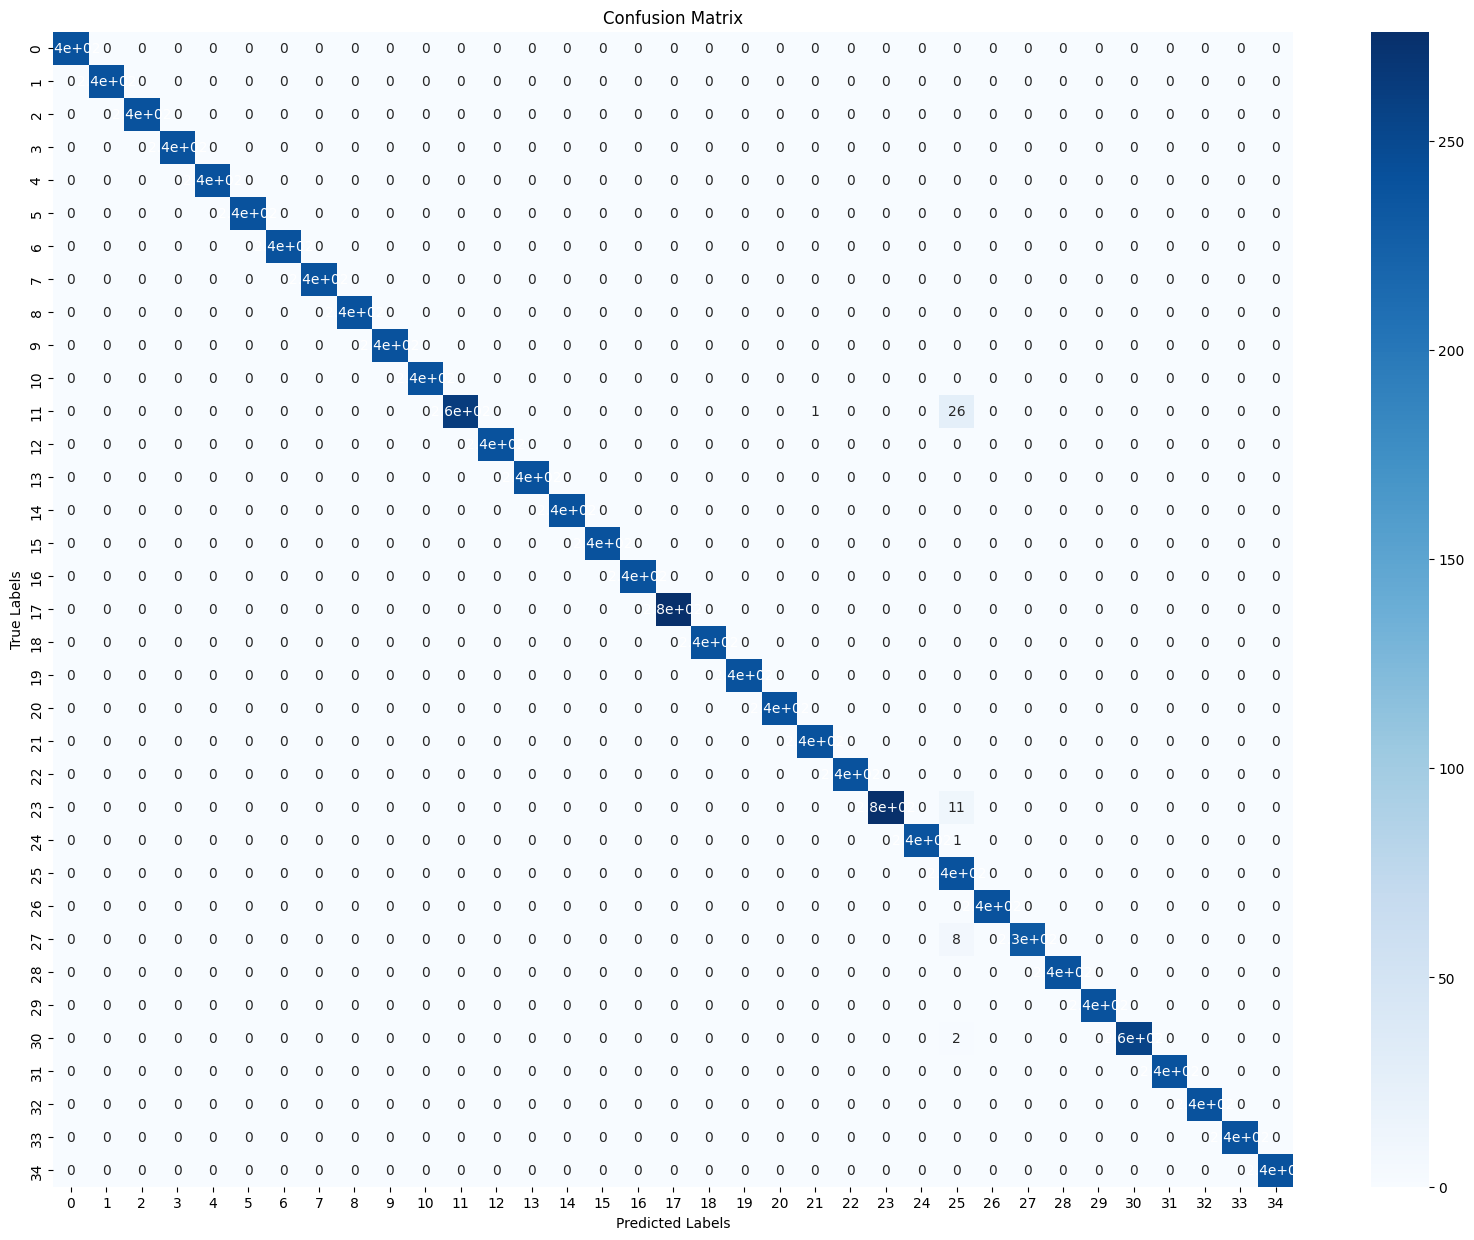


✅ Test Accuracy: 0.9943


In [14]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Load the trained model
model_path = "/kaggle/working/best_lstm_model.keras"  # Update this path if needed
model = tf.keras.models.load_model(model_path)
print("✅ Model Loaded Successfully!")

# ✅ Get model input shape using the correct attribute
model_input_shape = model.input_shape
print(f"Model expects input shape: {model_input_shape}")

# ✅ Check current shape of X_test
print(f"Current X_test shape: {X_test.shape}")

# ✅ Prepare X_test based on model's expected input shape
try:
    # Calculate the number of features expected by the model
    if model_input_shape and len(model_input_shape) == 3:
        expected_features = model_input_shape[2]
        
        # Check if X_test needs reshaping
        if len(X_test.shape) == 2:
            # X_test is (samples, features) - reshape to (samples, 1, features)
            if X_test.shape[1] == expected_features:
                X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
                print(f"Reshaped X_test from {X_test.shape} to {X_test_reshaped.shape}")
            else:
                print(f"WARNING: X_test has {X_test.shape[1]} features but model expects {expected_features}")
                # Try to adapt - might need manual intervention
                X_test_reshaped = X_test
        elif len(X_test.shape) == 3:
            # Already 3D, check if dimensions match
            if X_test.shape[1:] == model_input_shape[1:]:
                X_test_reshaped = X_test
                print("X_test already has the correct shape")
            else:
                print(f"WARNING: X_test shape {X_test.shape} doesn't match model input {model_input_shape}")
                # Try a simple reshape if total elements match
                X_test_reshaped = X_test.reshape((X_test.shape[0], model_input_shape[1], model_input_shape[2]))
                print(f"Attempted to reshape X_test to {X_test_reshaped.shape}")
        else:
            # Unexpected dimensionality
            print("ERROR: X_test has unexpected dimensionality")
            X_test_reshaped = X_test
    else:
        # Can't determine expected shape
        print("WARNING: Could not determine model's expected input shape")
        X_test_reshaped = X_test
        
except Exception as e:
    print(f"Error preparing test data: {e}")
    # Alternative method: try getting shape from model summary
    print("Printing model summary for diagnostic purposes:")
    model.summary()
    # Last resort approach - use original X_test
    X_test_reshaped = X_test

# ✅ Make Predictions with proper error handling
try:
    print("\nMaking predictions...")
    y_pred_probs = model.predict(X_test_reshaped)  # Predicted probabilities
    y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
    y_true = np.argmax(y_test, axis=1)  # Convert one-hot labels to class indices

    # ✅ Print Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # ✅ Compute Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred)
    print(conf_matrix)
    # ✅ Plot Confusion Matrix
    plt.figure(figsize=(20, 15))
    sns.heatmap(conf_matrix, annot=True, cmap="Blues")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

    # ✅ Print accuracy
    accuracy = (y_pred == y_true).sum() / len(y_true)
    print(f"\n✅ Test Accuracy: {accuracy:.4f}")
    
except Exception as e:
    print(f"Error during prediction or evaluation: {e}")
    
    # Print shape information for debugging
    print("\nDEBUG INFORMATION:")
    print(f"X_test_reshaped shape: {X_test_reshaped.shape}")
    print(f"y_test shape: {y_test.shape}")
    
    # Get layer-by-layer info
    print("\nModel architecture details:")
    for i, layer in enumerate(model.layers):
        print(f"Layer {i}: {layer.name}, type: {type(layer).__name__}")
        try:
            print(f"  Input shape: {layer.input_shape}")
            print(f"  Output shape: {layer.output_shape}")
        except:
            print("  Could not retrieve shape information")